# 07 - VADER: sentiment is not stance
VADER is a rule-based sentiment lexicon for social media (Hutto and Gilbert, 2014). It returns a compound score in [-1, 1] from the words in a tweet. The vaccine labels are stance (pro, anti, or neutral toward vaccines), not general sentiment. This notebook checks how far a sentiment score gets on the shared validation split, without writing into the shared results table.


In [1]:
%matplotlib inline
import os, sys

if "google.colab" in sys.modules:
    %pip install -q emoji vaderSentiment
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
    try:
        import vaderSentiment  # noqa: F401
    except ImportError:
        %pip install -q vaderSentiment

for d in ["data/processed", "reports/figures", "reports"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
if BASE not in sys.path:
    sys.path.insert(0, BASE)

FIG = "reports/figures/"
print("BASE =", BASE)


BASE = /Users/mac/formative2-vaccine-sentiment


## Data
Splits come only from `load_splits()`. The VADER input is `safe_text` with `<user>` and `<url>` removed. Case and punctuation stay, because VADER uses them.


In [2]:
import re
import json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix, f1_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer, SentiText

from src.preprocessing import load_splits
from src.evaluation import score, LABELS, LABEL_NAMES

train, val, test = load_splits()
TAG_RE = re.compile(r"<\s*(user|url)\s*>", re.IGNORECASE)

def vader_text(s):
    return TAG_RE.sub(" ", str(s)).strip()

for df in (train, val, test):
    df["text"] = df["safe_text"].map(vader_text)

print("sizes", len(train), len(val), len(test))
print("example:", repr(train["text"].iloc[0][:120]))


sizes 6689 1433 1434
example: '#Vaccinations are important RT   Measles cases in California outbreak keep rising — now at almost 80.'


## VADER compound scores
Each split is scored once. The continuous compound score is kept for RMSE and for the Spearman correlation with the stance label.


In [3]:
sia = SentimentIntensityAnalyzer()

def compound_scores(texts):
    return np.array([sia.polarity_scores(t)["compound"] for t in texts], dtype=float)

for name, df in [("train", train), ("val", val), ("test", test)]:
    df["compound"] = compound_scores(df["text"])
    print(name, "compound mean", round(float(df["compound"].mean()), 4),
          "std", round(float(df["compound"].std()), 4))

# measles / outbreak are not in the lexicon
demo = "Measles cases in California outbreak keep rising"
print("demo tweet:", repr(demo))
print("measles in lexicon?", "measles" in sia.lexicon)
print("outbreak in lexicon?", "outbreak" in sia.lexicon)
print("demo polarity_scores:", sia.polarity_scores(demo))


train compound mean -0.0244 std 0.4347
val compound mean -0.0419 std 0.44


test compound mean -0.0581 std 0.4414
demo tweet: 'Measles cases in California outbreak keep rising'
measles in lexicon? False
outbreak in lexicon? False
demo polarity_scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


## Mapping compound to -1 / 0 / 1
Version A uses the usual VADER cutoffs at +/-0.05. Version B picks one symmetric threshold on the training split only (grid 0.05 to 0.6, step 0.05) to maximise macro-F1, then applies that threshold to validation and test.


In [4]:
def map_compound(compound, threshold):
    y = np.zeros(len(compound), dtype=int)
    y[compound >= threshold] = 1
    y[compound <= -threshold] = -1
    return y

def row_metrics(version, split_name, y_true, y_pred, compound, threshold):
    macro_f1, rmse = score(y_true, y_pred, y_score=compound)
    per = f1_score(y_true, y_pred, labels=LABELS, average=None, zero_division=0)
    rho, pval = spearmanr(compound, y_true)
    return {
        "version": version,
        "split": split_name,
        "threshold": threshold,
        "macro_f1": macro_f1,
        "rmse": rmse,
        "f1_negative": per[0],
        "f1_neutral": per[1],
        "f1_positive": per[2],
        "spearman": rho,
        "spearman_p": pval,
    }

THRESH_A = 0.05
rows = []
for split_name, df in [("train", train), ("val", val), ("test", test)]:
    pred = map_compound(df["compound"].values, THRESH_A)
    rows.append(row_metrics("A_standard", split_name, df["label"].values, pred,
                            df["compound"].values, THRESH_A))

grid = np.round(np.arange(0.05, 0.61, 0.05), 2)
grid_rows = []
best_t, best_f1 = None, -1.0
for t in grid:
    pred = map_compound(train["compound"].values, t)
    f1, _ = score(train["label"].values, pred, y_score=train["compound"].values)
    grid_rows.append({"threshold": t, "train_macro_f1": f1})
    if f1 > best_f1:
        best_f1, best_t = f1, float(t)

THRESH_B = best_t
print("train threshold grid (macro-F1):")
display(pd.DataFrame(grid_rows).round(4))
print(f"chosen threshold B = {THRESH_B} (train macro-F1 {best_f1:.4f})")

for split_name, df in [("train", train), ("val", val), ("test", test)]:
    pred = map_compound(df["compound"].values, THRESH_B)
    rows.append(row_metrics("B_tuned", split_name, df["label"].values, pred,
                            df["compound"].values, THRESH_B))

results = pd.DataFrame(rows).round(4)
results.to_csv("reports/vader_val_results.csv", index=False)
print("saved reports/vader_val_results.csv")
display(results)

print("\nValidation focus:")
display(results[results["split"] == "val"].round(4))
print("\nTest reference rows:")
display(results[results["split"] == "test"].round(4))


train threshold grid (macro-F1):


,threshold,train_macro_f1
0,0.05,0.3490
1,0.10,0.3523
2,0.15,0.3540
3,0.20,0.3535
4,0.25,0.3527
5,0.30,0.3566
6,0.35,0.3561
7,0.40,0.3524
8,0.45,0.3405
9,0.50,0.3332


chosen threshold B = 0.3 (train macro-F1 0.3566)
saved reports/vader_val_results.csv


,version,split,threshold,macro_f1,rmse,f1_negative,f1_neutral,f1_positive,spearman,spearman_p
0,A_standard,train,0.05,0.3490,0.8449,0.2020,0.4596,0.3854,0.0028,0.8164
1,A_standard,val,0.05,0.3242,0.8573,0.1928,0.4236,0.3562,-0.0058,0.8254
2,A_standard,test,0.05,0.3377,0.8589,0.2135,0.4372,0.3626,0.0073,0.7827
3,B_tuned,train,0.30,0.3566,0.8449,0.1925,0.5363,0.3412,0.0028,0.8164
4,B_tuned,val,0.30,0.3444,0.8573,0.1975,0.5144,0.3214,-0.0058,0.8254
5,B_tuned,test,0.30,0.3503,0.8589,0.2069,0.5305,0.3136,0.0073,0.7827



Validation focus:


,version,split,threshold,macro_f1,rmse,f1_negative,f1_neutral,f1_positive,spearman,spearman_p
1,A_standard,val,0.05,0.3242,0.8573,0.1928,0.4236,0.3562,-0.0058,0.8254
4,B_tuned,val,0.30,0.3444,0.8573,0.1975,0.5144,0.3214,-0.0058,0.8254



Test reference rows:


,version,split,threshold,macro_f1,rmse,f1_negative,f1_neutral,f1_positive,spearman,spearman_p
2,A_standard,test,0.05,0.3377,0.8589,0.2135,0.4372,0.3626,0.0073,0.7827
5,B_tuned,test,0.30,0.3503,0.8589,0.2069,0.5305,0.3136,0.0073,0.7827


## Simple reference predictors on validation
Two cheap baselines on the validation labels: always predict neutral, and a random predictor that draws labels with the validation class proportions (seed 42, 500 draws).


In [5]:
y_val = val["label"].to_numpy()
majority_pred = np.zeros(len(y_val), dtype=int)  # always neutral = 0
majority_f1 = f1_score(y_val, majority_pred, labels=LABELS, average="macro", zero_division=0)

props = pd.Series(y_val).value_counts(normalize=True).reindex(LABELS).fillna(0.0).to_numpy()
rng = np.random.default_rng(42)
rand_f1s = []
for _ in range(500):
    pred = rng.choice(LABELS, size=len(y_val), p=props)
    rand_f1s.append(f1_score(y_val, pred, labels=LABELS, average="macro", zero_division=0))
random_f1_mean = float(np.mean(rand_f1s))

val_A = float(results[(results.version == "A_standard") & (results.split == "val")]["macro_f1"].iloc[0])
val_B = float(results[(results.version == "B_tuned") & (results.split == "val")]["macro_f1"].iloc[0])
print("always-neutral macro-F1:", round(majority_f1, 4))
print("random-by-proportions mean macro-F1 (500 draws, seed 42):", round(random_f1_mean, 4))
print("class proportions used:", dict(zip(LABELS, np.round(props, 4))))
print("VADER A val macro-F1:", round(val_A, 4))
print("VADER B val macro-F1:", round(val_B, 4))


always-neutral macro-F1: 0.2171
random-by-proportions mean macro-F1 (500 draws, seed 42): 0.333
class proportions used: {-1: 0.1068, 0: 0.4829, 1: 0.4103}
VADER A val macro-F1: 0.3242
VADER B val macro-F1: 0.3444


## Validation confusion matrices and compound by label
Metrics above use `src.evaluation.score` for macro-F1 and RMSE (compound versus the stance label). Figures use the validation split.


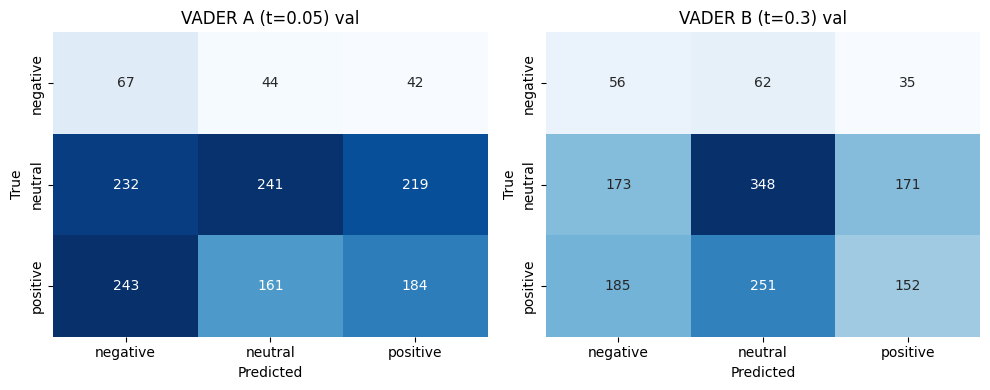

saved reports/figures/vader_confusion.png


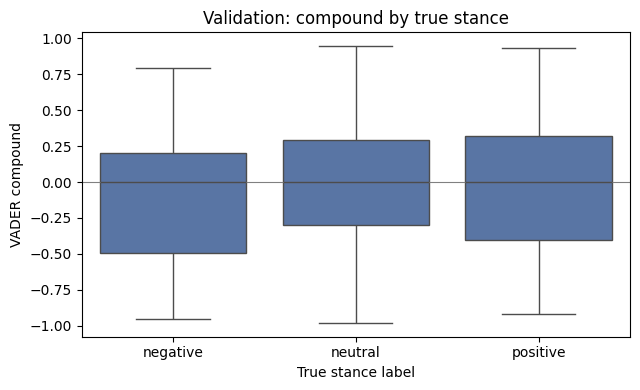

saved reports/figures/vader_compound_by_label.png


In [6]:
def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

pred_val_A = map_compound(val["compound"].values, THRESH_A)
pred_val_B = map_compound(val["compound"].values, THRESH_B)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm(axes[0], val["label"].values, pred_val_A, f"VADER A (t={THRESH_A}) val")
plot_cm(axes[1], val["label"].values, pred_val_B, f"VADER B (t={THRESH_B}) val")
plt.tight_layout()
plt.savefig(FIG + "vader_confusion.png", dpi=200)
plt.show()
plt.close()
print("saved", FIG + "vader_confusion.png")

fig, ax = plt.subplots(figsize=(6.5, 4))
plot_df = val[["label", "compound"]].copy()
plot_df["label_name"] = plot_df["label"].map({-1: "negative", 0: "neutral", 1: "positive"})
sns.boxplot(data=plot_df, x="label_name", y="compound",
            order=["negative", "neutral", "positive"], ax=ax, color="#4c72b0")
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel("True stance label")
ax.set_ylabel("VADER compound")
ax.set_title("Validation: compound by true stance")
plt.tight_layout()
plt.savefig(FIG + "vader_compound_by_label.png", dpi=200)
plt.show()
plt.close()
print("saved", FIG + "vader_compound_by_label.png")


## Disagreement rates and examples
Share of validation tweets where stance and compound disagree in sign, then fifteen extreme examples chosen only to illustrate.


In [7]:
n_pos_stance = int((val["label"] == 1).sum())
n_neg_stance = int((val["label"] == -1).sum())
pos_neg_mask = (val["label"] == 1) & (val["compound"] < -0.05)
neg_pos_mask = (val["label"] == -1) & (val["compound"] > 0.05)
share_pos_neg = float(pos_neg_mask.sum() / n_pos_stance)
share_neg_pos = float(neg_pos_mask.sum() / n_neg_stance)
print("positive-stance tweets:", n_pos_stance)
print("share with compound < -0.05:", round(share_pos_neg, 4),
      f"({int(pos_neg_mask.sum())}/{n_pos_stance})")
print("negative-stance tweets:", n_neg_stance)
print("share with compound > 0.05:", round(share_neg_pos, 4),
      f"({int(neg_pos_mask.sum())}/{n_neg_stance})")

val_ex = val.copy()
val_ex["vader_label"] = map_compound(val_ex["compound"].values, THRESH_B)
pos_stance_neg_sent = val_ex[pos_neg_mask].sort_values("compound")
neg_stance_pos_sent = val_ex[neg_pos_mask].sort_values("compound", ascending=False)

n_pos = min(8, len(pos_stance_neg_sent))
n_neg = min(15 - n_pos, len(neg_stance_pos_sent))
examples = pd.concat([pos_stance_neg_sent.head(n_pos), neg_stance_pos_sent.head(n_neg)],
                     ignore_index=True)
examples = examples[["tweet_id", "text", "label", "compound", "vader_label"]].copy()
examples["compound"] = examples["compound"].round(4)
examples.to_csv("reports/vader_examples.csv", index=False)
print("saved reports/vader_examples.csv (", len(examples), "rows)")
print("These 15 are the most extreme compounds in each disagreement direction (illustrative only).")

print("\nExamples (true label, compound, VADER label):")
for i, r in examples.iterrows():
    print("-" * 72)
    print(f"[{i+1}] true={int(r['label'])}  compound={r['compound']:.4f}  vader={int(r['vader_label'])}")
    print(r["text"])

ex14 = examples.iloc[13]
print("\nExample 14 check:")
print("true label:", int(ex14["label"]), "compound:", float(ex14["compound"]))
print("text:", ex14["text"])


positive-stance tweets: 588
share with compound < -0.05: 0.4133 (243/588)
negative-stance tweets: 153
share with compound > 0.05: 0.2745 (42/153)
saved reports/vader_examples.csv ( 15 rows)
These 15 are the most extreme compounds in each disagreement direction (illustrative only).

Examples (true label, compound, VADER label):
------------------------------------------------------------------------
[1] true=1  compound=-0.9200  vader=-1
because they're fucking stupid, not taking vaccines and believing every conspiracy theory out there. Ugh I'm mad now
------------------------------------------------------------------------
[2] true=1  compound=-0.9199  vader=-1
I'm gonna be so pissed if I get polio or the Black Death because some misinformed bimbo parents don't want Jimmy or Sally to be vaccinated
------------------------------------------------------------------------
[3] true=1  compound=-0.9109  vader=-1
We have all but eradicated terrible diseases with the use of vaccines, yet peop

## Lexicon words in the disagreement examples
Using `sia.lexicon`, count which lexicon words appear in the eight positive-stance examples and in the seven negative-stance examples. Disease words such as measles are checked separately.


In [8]:
def lexicon_word_counts(texts):
    counts = Counter()
    valence = {}
    for text in texts:
        for w in SentiText(str(text)).words_and_emoticons:
            key = w.lower()
            if key in sia.lexicon:
                counts[key] += 1
                valence[key] = sia.lexicon[key]
    rows = [{"word": w, "count": c, "lexicon_valence": valence[w]}
            for w, c in counts.most_common()]
    return pd.DataFrame(rows)

pos_ex = examples[examples["label"] == 1]
neg_ex = examples[examples["label"] == -1]
print("n positive-stance examples:", len(pos_ex))
print("n negative-stance examples:", len(neg_ex))

pos_lex = lexicon_word_counts(pos_ex["text"])
neg_lex = lexicon_word_counts(neg_ex["text"])
print("\nLexicon words in the 8 positive-stance examples (most frequent first):")
display(pos_lex.head(15))
print("\nLexicon words in the negative-stance examples (most frequent first):")
display(neg_lex.head(15))

for w in ["measles", "outbreak", "stupid", "fucking", "tragic", "killing", "good", "healthy", "like", "safe"]:
    print(f"{w!r} in lexicon?", w in sia.lexicon,
          "valence=", sia.lexicon[w] if w in sia.lexicon else None)

# BERTweet seed-42 validation RMSE from experiment_log
log = pd.read_csv("reports/experiment_log.csv")
bt = log[log["model"] == "bertweet"].copy()
bt_e3_42 = bt[bt["params"].apply(
    lambda p: json.loads(p).get("exp") == "E3" and json.loads(p).get("seed") == 42
)].iloc[0]
vader_val_rmse = float(results[(results.version == "A_standard") & (results.split == "val")]["rmse"].iloc[0])
print("\nVADER validation RMSE (compound vs label):", round(vader_val_rmse, 4))
print("BERTweet E3 seed-42 validation RMSE:", float(bt_e3_42["val_rmse"]))
print("BERTweet E3 seed-42 validation macro-F1:", float(bt_e3_42["val_macro_f1"]))


n positive-stance examples: 8
n negative-stance examples: 7

Lexicon words in the 8 positive-stance examples (most frequent first):


,word,count,lexicon_valence
0,stupid,2,-2.4
1,death,2,-2.9
2,want,2,0.3
3,stop,2,-1.2
4,conspiracy,1,-2.4
5,ugh,1,-1.8
6,mad,1,-2.2
7,pissed,1,-3.2
8,misinformed,1,-1.6
9,terrible,1,-2.1



Lexicon words in the negative-stance examples (most frequent first):


,word,count,lexicon_valence
0,innocent,1,1.4
1,truth,1,1.3
2,justice,1,2.4
3,healthy,1,1.7
4,improve,1,1.9
5,immune,1,1.2
6,fear,1,-2.2
7,super,1,2.9
8,like,1,1.5
9,agree,1,1.5


'measles' in lexicon? False valence= None
'outbreak' in lexicon? False valence= None
'stupid' in lexicon? True valence= -2.4
'fucking' in lexicon? False valence= None
'tragic' in lexicon? True valence= -2.0
'killing' in lexicon? True valence= -3.4
'good' in lexicon? True valence= 1.9
'healthy' in lexicon? True valence= 1.7
'like' in lexicon? True valence= 1.5
'safe' in lexicon? True valence= 1.9

VADER validation RMSE (compound vs label): 0.8573
BERTweet E3 seed-42 validation RMSE: 0.5616
BERTweet E3 seed-42 validation macro-F1: 0.7432


## Analysis
Validation macro-F1 is 0.3242 for version A (threshold 0.05) and 0.3444 for version B (threshold 0.30 chosen on train). Always predicting neutral scores 0.2171 macro-F1 on the same validation labels. A random predictor that follows the validation class proportions averages 0.3330 over 500 draws (seed 42). Version A is close to that random mean; version B is only slightly above it (0.3444). Both remain far below BERTweet's E3 seed-42 validation macro-F1 of 0.7432.

Per-class F1 on validation for B is 0.1975 negative, 0.5144 neutral, 0.3214 positive. Spearman correlation between compound and label is -0.0058 on validation (p = 0.8254), so there is no useful monotonic link on this split. Of positive-stance validation tweets, 0.4133 have compound below -0.05 (243 of 588). Of negative-stance tweets, 0.2745 have compound above 0.05 (42 of 153).

VADER's compound against the label gives RMSE 0.8573 on validation, against 0.5616 for the BERTweet seed-42 validation RMSE in reports/experiment_log.csv. The compound is not on the same scale as a trained prediction, so the comparison is rough.

The words measles and outbreak are not in the VADER lexicon: the tweet "Measles cases in California outbreak keep rising" scores compound 0.0. In the eight positive-stance disagreement examples, the lexicon words that appear most often are stupid, death, want and stop (each twice), followed by single hits such as conspiracy, ugh, mad, pissed, tragic, sick and bastard. Those are mostly negative-valence lexicon entries, which explains the strongly negative compounds. In the seven negative-stance examples, the frequent lexicon hits are positive-valence words such as innocent, truth, justice, healthy, improve, immune, super, like, agree, good, approved, comfortable and safe.

The fifteen printed examples are the most extreme cases, chosen to illustrate, not typical ones. Example 14 ("Good! LA Times - Bill removing California vaccine exemptions...") is labelled -1 although it reads as pro-vaccine, so it may be a label error, and it is not used here as an example of positive framing by an anti-vaccine writer.

Test rows are only a reference: A macro-F1 0.3377, B macro-F1 0.3503. Tuning the threshold on train only lifts validation macro-F1 by about 0.02 and still leaves VADER near the random baseline. A lexicon sentiment score does not recover vaccine stance on this split.
